# Machine Learning Clásico
## HOG Feature Extraction + Clasificadores ML

Pipeline: **HOG features** → SVM / Random Forest / KNN  
Este enfoque replica la práctica de clase (HOG + SVM para detección con ML clásico).

**Objetivo:** Establecer un baseline antes de pasar a Deep Learning.

---
**Índice:**
1. Setup
2. Carga y preprocesado de imágenes
3. Extracción de features HOG
4. Entrenamiento de clasificadores
5. Evaluación y comparativa
6. Conclusiones — baseline para DL

## 1. Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q scikit-image scikit-learn

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from PIL import Image
from tqdm.notebook import tqdm
from skimage.feature import hog
from skimage import exposure

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, f1_score
)
import pandas as pd

BASE_PATH = '/content/drive/MyDrive/Trabajo_no_estructurados_imagen/data'
TRAIN_DIR = os.path.join(BASE_PATH, 'Training')
TEST_DIR  = os.path.join(BASE_PATH, 'Testing')

CLASES     = sorted(os.listdir(TRAIN_DIR))
CLASS_IDX  = {c: i for i, c in enumerate(CLASES)}
IDX_CLASS  = {i: c for c, i in CLASS_IDX.items()}
PALETTE    = dict(zip(CLASES, ['#4C72B0', '#DD8452', '#55A868', '#C44E52']))
IMG_SIZE   = (64, 64)   # tamaño para HOG (64x64 es estándar)

random.seed(42)
np.random.seed(42)

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,
                     'axes.spines.right': False})
print('Clases:', CLASES)

Clases: ['glioma', 'meningioma', 'notumor', 'pituitary']


## 2. Carga y preprocesado de imágenes

In [ ]:
def load_images(base_dir, clases, img_size, split_name=''):
    """
    Carga todas las imágenes de base_dir/clase/,
    las redimensiona a img_size y devuelve arrays numpy.
    """
    X, y = [], []
    for clase in tqdm(clases, desc=f'Cargando [{split_name}]'):
        folder = os.path.join(base_dir, clase)
        for fname in os.listdir(folder):
            try:
                img = Image.open(os.path.join(folder, fname)).convert('L')  # escala de grises
                img = img.resize(img_size)
                X.append(np.array(img))
                y.append(CLASS_IDX[clase])
            except Exception:
                pass
    return np.array(X), np.array(y)


X_train_imgs, y_train = load_images(TRAIN_DIR, CLASES, IMG_SIZE, 'train')
X_test_imgs,  y_test  = load_images(TEST_DIR,  CLASES, IMG_SIZE, 'test')

print(f'\nTrain: {X_train_imgs.shape}  →  {len(y_train)} etiquetas')
print(f'Test:  {X_test_imgs.shape}   →  {len(y_test)} etiquetas')

Cargando [train]:   0%|          | 0/4 [00:00<?, ?it/s]

Cargando [test]:   0%|          | 0/4 [00:00<?, ?it/s]


Train: (5600, 64, 64)  →  5600 etiquetas
Test:  (1600, 64, 64)   →  1600 etiquetas


## 3. Extracción de features HOG

**HOG (Histogram of Oriented Gradients):** captura la distribución de gradientes de intensidad  
en regiones locales de la imagen.
Parámetros clave:
- `pixels_per_cell`: tamaño de cada celda donde se computa el histograma
- `cells_per_block`: normalización local de contraste
- `orientations`: número de bins del histograma de gradientes

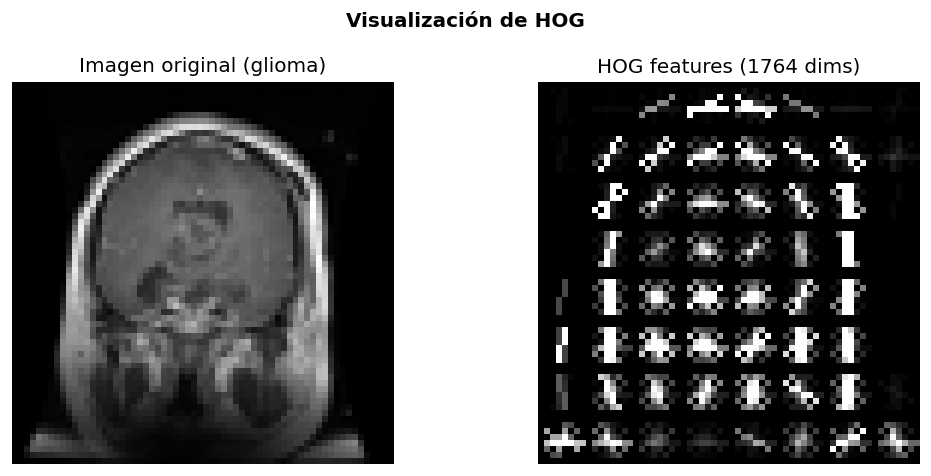

Dimensión del vector HOG: 1764


In [ ]:
# Visualizar HOG sobre una imagen de ejemplo
sample_folder = os.path.join(TRAIN_DIR, CLASES[0])
sample_path   = os.path.join(sample_folder, os.listdir(sample_folder)[0])
sample_img    = np.array(Image.open(sample_path).convert('L').resize(IMG_SIZE))

fd, hog_image = hog(
    sample_img,
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    visualize=True,
    block_norm='L2-Hys'
)

hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(sample_img, cmap='gray')
axes[0].set_title(f'Imagen original ({CLASES[0]})')
axes[0].axis('off')
axes[1].imshow(hog_image_rescaled, cmap='gray')
axes[1].set_title(f'HOG features ({len(fd)} dims)')
axes[1].axis('off')
plt.suptitle('Visualización de HOG', fontweight='bold')
plt.tight_layout()
plt.savefig('ml_01_hog_visual.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Dimensión del vector HOG: {len(fd)}')

In [ ]:
# Extraer HOG de todas las imágenes
HOG_PARAMS = dict(
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    block_norm='L2-Hys'
)

def extract_hog(images, params):
    features = []
    for img in tqdm(images, desc='Extrayendo HOG'):
        fd = hog(img, **params)
        features.append(fd)
    return np.array(features)


X_train_hog = extract_hog(X_train_imgs, HOG_PARAMS)
X_test_hog  = extract_hog(X_test_imgs,  HOG_PARAMS)

print(f'\nFeatures HOG — Train: {X_train_hog.shape}')
print(f'Features HOG — Test:  {X_test_hog.shape}')

# Normalizar con StandardScaler (importante para SVM y KNN)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_hog)
X_test_sc  = scaler.transform(X_test_hog)
print('\nFeatures normalizados con StandardScaler.')

Extrayendo HOG:   0%|          | 0/5600 [00:00<?, ?it/s]

Extrayendo HOG:   0%|          | 0/1600 [00:00<?, ?it/s]


Features HOG — Train: (5600, 1764)
Features HOG — Test:  (1600, 1764)

Features normalizados con StandardScaler.


## 4. Entrenamiento de clasificadores

In [ ]:
classifiers = {
    'SVM (RBF)':      SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42),
    'SVM (Linear)':   SVC(kernel='linear', C=1, probability=True, random_state=42),
    'Random Forest':  RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42),
    'KNN (k=5)':      KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
}

resultados = {}

for nombre, clf in classifiers.items():
    print(f'▷ Entrenando {nombre}...')
    t0 = time.time()
    clf.fit(X_train_sc, y_train)
    t_train = time.time() - t0

    y_pred_train = clf.predict(X_train_sc)
    y_pred_test  = clf.predict(X_test_sc)

    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test  = accuracy_score(y_test,  y_pred_test)
    f1        = f1_score(y_test, y_pred_test, average='macro')

    resultados[nombre] = {
        'y_pred': y_pred_test,
        'acc_train': acc_train,
        'acc_test':  acc_test,
        'f1_macro':  f1,
        'f1_per':    f1_score(y_test, y_pred_test, average=None),
        't_s':       round(t_train, 1),
    }

    gap = acc_train - acc_test
    print(f'   Train: {acc_train*100:.2f}%  Test: {acc_test*100:.2f}%  '
          f'F1: {f1*100:.2f}%  Gap: {gap*100:+.2f}%  ({t_train:.1f}s)')

print('\n Entrenamiento completado.')

▷ Entrenando SVM (RBF)...
   Train: 100.00%  Test: 90.50%  F1: 90.19%  Gap: +9.50%  (160.5s)
▷ Entrenando SVM (Linear)...
   Train: 100.00%  Test: 80.44%  F1: 80.13%  Gap: +19.56%  (68.6s)
▷ Entrenando Random Forest...
   Train: 100.00%  Test: 83.56%  F1: 82.89%  Gap: +16.44%  (57.0s)
▷ Entrenando KNN (k=5)...
   Train: 94.57%  Test: 83.50%  F1: 82.91%  Gap: +11.07%  (0.0s)

 Entrenamiento completado.


## 5. Evaluación y comparativa

In [ ]:
# Tabla comparativa
rows = []
for nombre, res in resultados.items():
    rows.append({
        'Modelo': nombre,
        'Train Acc (%)': round(res['acc_train']*100, 2),
        'Test Acc (%)':  round(res['acc_test']*100,  2),
        'F1 macro (%)':  round(res['f1_macro']*100,  2),
        'Gap (%)':       round((res['acc_train'] - res['acc_test'])*100, 2),
        'T. train (s)':  res['t_s'],
    })

df = pd.DataFrame(rows).sort_values('Test Acc (%)', ascending=False).reset_index(drop=True)
display(df.style
    .highlight_max(subset=['Test Acc (%)', 'F1 macro (%)'], color='#d4edda')
    .format({'Gap (%)': '{:+.2f}'})
    .set_caption('Comparativa — ML clásico con HOG features'))

,Modelo,Train Acc (%),Test Acc (%),F1 macro (%),Gap (%),T. train (s)
0,SVM (RBF),100.000000,90.500000,90.190000,+9.50,160.500000
1,Random Forest,100.000000,83.560000,82.890000,+16.44,57.000000
2,KNN (k=5),94.570000,83.500000,82.910000,+11.07,0.000000
3,SVM (Linear),100.000000,80.440000,80.130000,+19.56,68.600000


Todos los modelos muestran overfitting, especialmente SVM Linear y Random Forest
(gap >15%). SVM RBF es el más equilibrado con 90.5% de test accuracy y un gap
de +9.5%, siendo el mejor baseline para comparar con Deep Learning.
El overfitting es inherente a features de alta dimensión (HOG ~1764 dims)
con clasificadores clásicos sin regularización adicional.

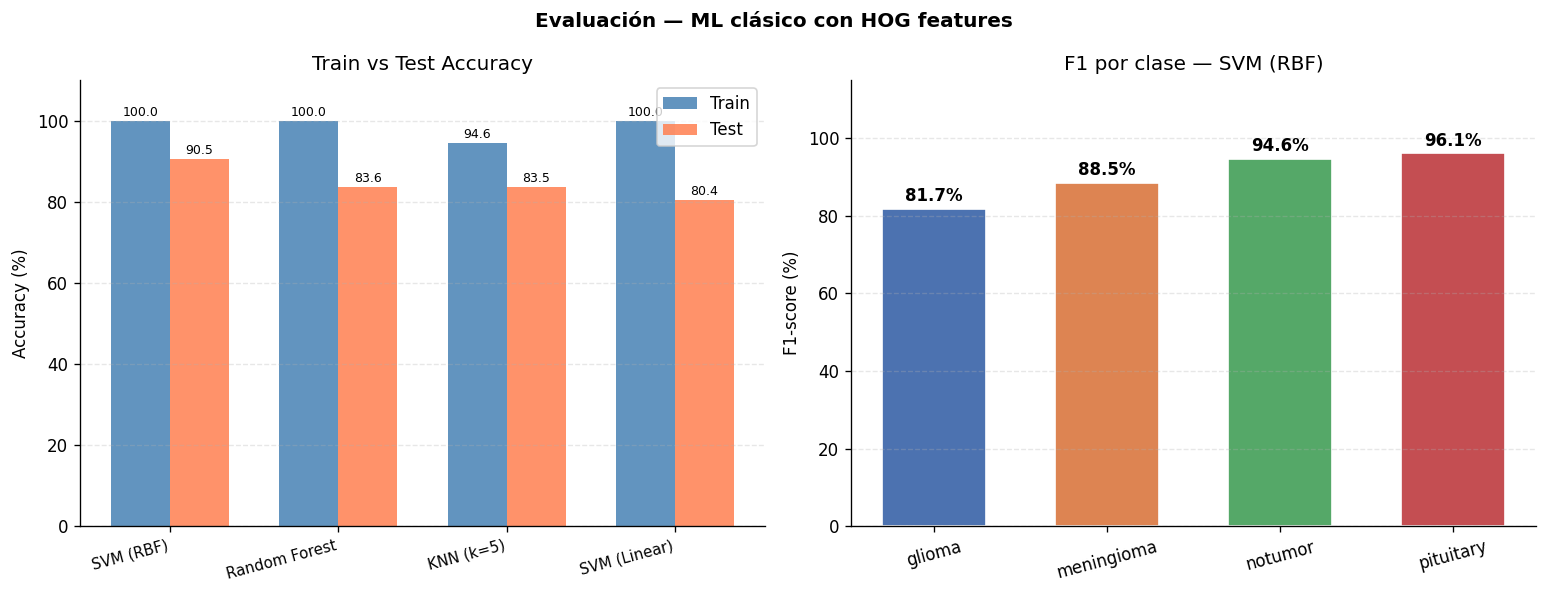

In [ ]:
# Barplot Train vs Test Accuracy
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Evaluación — ML clásico con HOG features', fontweight='bold')

modelos = df['Modelo'].values
x = np.arange(len(modelos))
w = 0.35

axes[0].bar(x - w/2, df['Train Acc (%)'], w, label='Train', color='steelblue', alpha=0.85)
axes[0].bar(x + w/2, df['Test Acc (%)'],  w, label='Test',  color='coral',     alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(modelos, rotation=15, ha='right', fontsize=9)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(0, 110)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
axes[0].set_title('Train vs Test Accuracy')
for i, (tr, te) in enumerate(zip(df['Train Acc (%)'], df['Test Acc (%)'])):
    axes[0].text(i - w/2, tr + 0.5, f'{tr:.1f}', ha='center', va='bottom', fontsize=7.5)
    axes[0].text(i + w/2, te + 0.5, f'{te:.1f}', ha='center', va='bottom', fontsize=7.5)

# F1 por clase del mejor modelo
best_name = df.iloc[0]['Modelo']
f1s = resultados[best_name]['f1_per'] * 100
bars = axes[1].bar(CLASES, f1s, color=[PALETTE[c] for c in CLASES], edgecolor='white', width=0.6)
axes[1].set_title(f'F1 por clase — {best_name}')
axes[1].set_ylabel('F1-score (%)')
axes[1].set_ylim(0, 115)
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')
for bar, v in zip(bars, f1s):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{v:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('ml_02_comparativa.png', dpi=150, bbox_inches='tight')
plt.show()

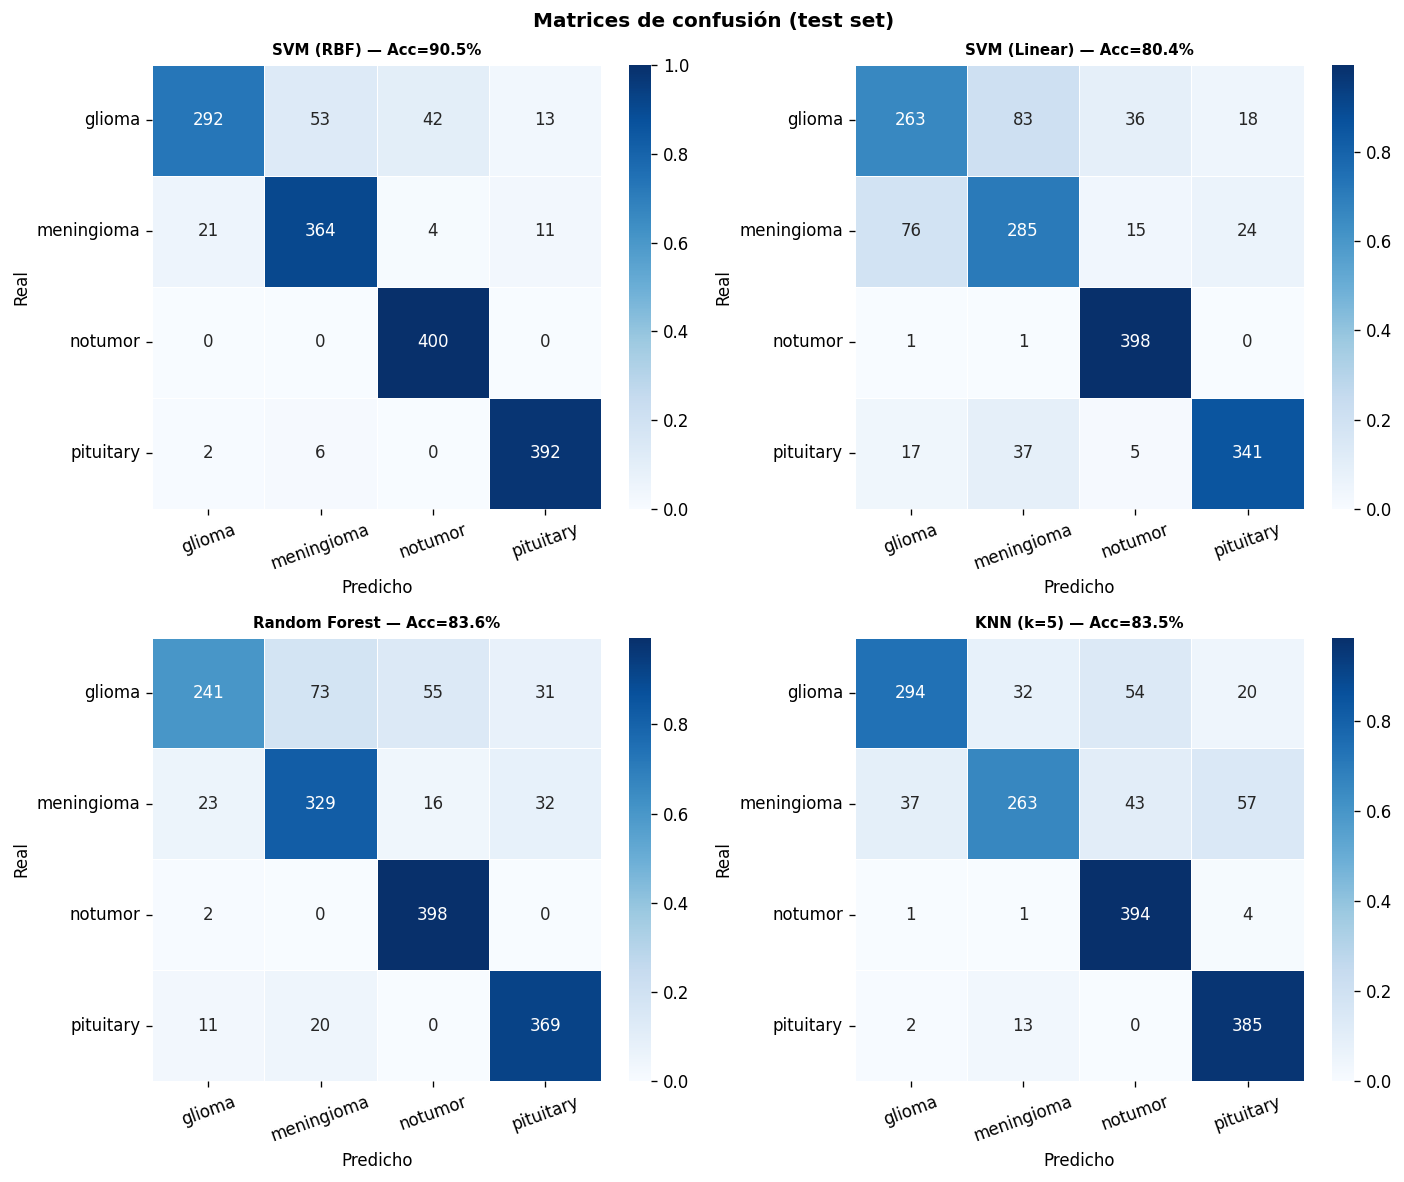

In [ ]:
# Matrices de confusión
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Matrices de confusión (test set)', fontsize=12, fontweight='bold')
axes = axes.flatten()

for ax, nombre in zip(axes, resultados.keys()):
    cm = confusion_matrix(y_test, resultados[nombre]['y_pred'])
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=cm, fmt='d', cmap='Blues',
                xticklabels=CLASES, yticklabels=CLASES,
                ax=ax, linewidths=0.5, annot_kws={'size': 10})
    acc = resultados[nombre]['acc_test']
    ax.set_title(f"{nombre} — Acc={acc*100:.1f}%", fontsize=9, fontweight='bold')
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')
    ax.tick_params(axis='x', rotation=20)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('ml_03_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Reporte completo del mejor modelo
print(f'Reporte de clasificación — {best_name}')
print(classification_report(y_test, resultados[best_name]['y_pred'],
                             target_names=CLASES, digits=4))

Reporte de clasificación — SVM (RBF)
              precision    recall  f1-score   support

      glioma     0.9270    0.7300    0.8168       400
  meningioma     0.8605    0.9100    0.8846       400
     notumor     0.8969    1.0000    0.9456       400
   pituitary     0.9423    0.9800    0.9608       400

    accuracy                         0.9050      1600
   macro avg     0.9067    0.9050    0.9019      1600
weighted avg     0.9067    0.9050    0.9019      1600



In [ ]:
# ── Reducir dimensionalidad con PCA antes de entrenar ──────────────
from sklearn.decomposition import PCA

pca = PCA(n_components=100, random_state=42)
X_train_pca = pca.fit_transform(X_train_sc)
X_test_pca  = pca.transform(X_test_sc)

varianza = pca.explained_variance_ratio_.cumsum()[-1]
print(f'PCA(100) conserva el {varianza*100:.1f}% de la varianza original')

# ── Clasificadores con regularización ajustada ─────────────────────
classifiers_reg = {
    'SVM (RBF) + PCA':     SVC(kernel='rbf', C=1, gamma='scale', probability=True, random_state=42),
    'SVM (Linear) + PCA':  SVC(kernel='linear', C=0.1, probability=True, random_state=42),
    'Random Forest + PCA': RandomForestClassifier(n_estimators=200, max_depth=20, n_jobs=-1, random_state=42),
    'KNN (k=5) + PCA':     KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
}

resultados_reg = {}

for nombre, clf in classifiers_reg.items():
    t0 = time.time()
    clf.fit(X_train_pca, y_train)
    t_train = time.time() - t0

    y_pred_train = clf.predict(X_train_pca)
    y_pred_test  = clf.predict(X_test_pca)

    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test  = accuracy_score(y_test,  y_pred_test)
    f1        = f1_score(y_test, y_pred_test, average='macro')

    resultados_reg[nombre] = {
        'y_pred':    y_pred_test,
        'acc_train': acc_train,
        'acc_test':  acc_test,
        'f1_macro':  f1,
        'f1_per':    f1_score(y_test, y_pred_test, average=None),
        't_s':       round(t_train, 1),
    }

    gap = acc_train - acc_test
    print(f'▷ {nombre:<25}  Train: {acc_train*100:.2f}%  Test: {acc_test*100:.2f}%  '
          f'F1: {f1*100:.2f}%  Gap: {gap*100:+.2f}%  ({t_train:.1f}s)')

PCA(100) conserva el 69.2% de la varianza original
▷ SVM (RBF) + PCA            Train: 95.93%  Test: 85.81%  F1: 85.29%  Gap: +10.12%  (19.8s)
▷ SVM (Linear) + PCA         Train: 86.48%  Test: 75.19%  F1: 74.42%  Gap: +11.29%  (23.0s)
▷ Random Forest + PCA        Train: 100.00%  Test: 85.94%  F1: 85.46%  Gap: +14.06%  (13.9s)
▷ KNN (k=5) + PCA            Train: 95.18%  Test: 84.31%  F1: 83.81%  Gap: +10.87%  (0.0s)


## Conclusiones — Baseline para Deep Learning

El mejor modelo es **SVM con kernel RBF**, alcanzando un **90.5% de accuracy**
en test con HOG features. Se probó reducción de dimensionalidad con PCA(100)
para reducir el overfitting, pero el accuracy bajó a 85.8%, confirmando que
las 1764 dimensiones de HOG contienen información relevante que no conviene descartar.

El overfitting observado (gap ~10% en SVM RBF) es una limitación inherente
de los clasificadores clásicos con features de alta dimensión. Los modelos de
Deep Learning abordan esto de forma más natural mediante dropout, batch
normalization y data augmentation, por lo que el objetivo del Notebook 3
será superar el **90.5% de baseline** con redes convolucionales.